In [1]:
print("hi")

hi


In [2]:
# duckdb 라이브러리가 없을 경우 설치하라!
try:
    import duckdb
except:
    ! pip install duckdb

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import duckdb

In [4]:
pd.set_option("display.max_columns", None) # 모든 컬럼 보이도록 설정
plt.rcParams["figure.figsize"] = (8, 4) # 그래프의 크기 지정(가로 10, 세로 8)

## Predictive Maintenance Dataset (AI4I 2020)
- https://www.kaggle.com/datasets/hiimanshuagarwal/predictive-maintenance-dataset
- Kaggle 데이터는 합성(synthetic) 밀링 공정 기반의 예지보전/분류용 데이터이며,
- 제조 현장에서 자주 접하는 변수들(온도, 회전속도, 토크, 공구마모, 고장 여부 등)로 구성되어 있음.
- “고장 비율”, “변수별 분포”, “고장/정상 비교”, “상관관계”, “조건별 집계”, “이상치 탐색” 같은 EDA 주제를 만들기 쉽고,
- DuckDB로 그룹 집계와 구간화(binning) 실습도 깔끔함.
- 제조업 직장인에게는 “센서값과 고장 이벤트를 같이 보는 감각”을 익히기에 좋음.

In [5]:
df = pd.read_csv("ai4i2020.csv") #
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [6]:
df.shape # shape는 모양이라는 뜻으로 여기서는 (행의_갯수, 열의_갯수)를 알려줌.

(10000, 14)

In [7]:
df.info() # DataFrame의 정보(information)를 알려줌.
# 컬럼 별로 Non-Null Count(null이 아닌 데이터. 즉, 정상 데이터)와 Dtype(DataType, 데이터 타입)을 보여줌.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [8]:
df.isnull().sum() # 결측치 갯수를 얻을 수 있음. null 이 아닌 것들의 합계. 즉, 결칙치 갯수

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [9]:
df.duplicated().sum() # 중복된 데이터의 합을 보여줌. 0인 경우 중복된 데이터가 하나도 없다는 뜻

0

In [10]:
df.describe(include="all") # 기술적 분석 결과를 보여줌. include="all" 옵션은 모든 컬럼을 보여줌.

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
unique,NaN,10000,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,M14860,L,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5000.50000,NaN,NaN,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,NaN,NaN,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,NaN,NaN,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,NaN,NaN,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,NaN,NaN,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,NaN,NaN,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000


### 주요 컬럼
- `Type` : 제품 타입
- `Air temperature [K]` : 외기 온도
- `Process temperature [K]` : 공정 온도
- `Rotational speed [rpm]` : 회전 속도
- `Torque [Nm]` : 토크
- `Tool wear [min]` : 공구 마모 시간
- `Machine failure` : 전체 고장 여부
- `TWF`, `HDF`, `PWF`, `OSF`, `RNF` : 고장 유형 플래그

### 핵심 포인트
이 데이터는 단순한 숫자 표가 아니라,  
**설비 상태값과 고장 결과를 함께 보는 제조 데이터**라는 점이 중요하다.

In [11]:
# 전체 고장률
df["Machine failure"].mean()

0.0339

In [12]:
# 타입별 개수와 고장률
df.groupby("Type")["Machine failure"].agg(["count", "mean"]).sort_values("mean", ascending=False)

,count,mean
Type,,
L,6000,0.039167
M,2997,0.027694
H,1003,0.020937


In [13]:
# 고장/정상 평균 비교
cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

df.groupby("Machine failure")[cols].mean().T

Machine failure,0,1
Air temperature [K],299.973999,300.886431
Process temperature [K],309.995570,310.290265
Rotational speed [rpm],1540.260014,1496.486726
Torque [Nm],39.629655,50.168142
Tool wear [min],106.693717,143.781711


In [14]:
# 공정온도 - 외기온도 차이 파생변수
df["Temp_diff"] = df["Process temperature [K]"] - df["Air temperature [K]"]
df.groupby("Machine failure")["Temp_diff"].mean()

Machine failure
0    10.021571
1     9.403835
Name: Temp_diff, dtype: float64

In [15]:
# 공구 마모 구간별 고장률
df["wear_bin"] = pd.cut(
    df["Tool wear [min]"],
    bins=[0, 50, 100, 150, 200, 250],
    include_lowest=True
)

df.groupby("wear_bin")["Machine failure"].agg(["count", "mean"])

C:\Users\sam\AppData\Local\Temp\ipykernel_9588\3747432527.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("wear_bin")["Machine failure"].agg(["count", "mean"])


,count,mean
wear_bin,,
"(-0.001, 50.0]",2396,0.021703
"(50.0, 100.0]",2271,0.023338
"(100.0, 150.0]",2295,0.021786
"(150.0, 200.0]",2276,0.028998
"(200.0, 250.0]",760,0.152632


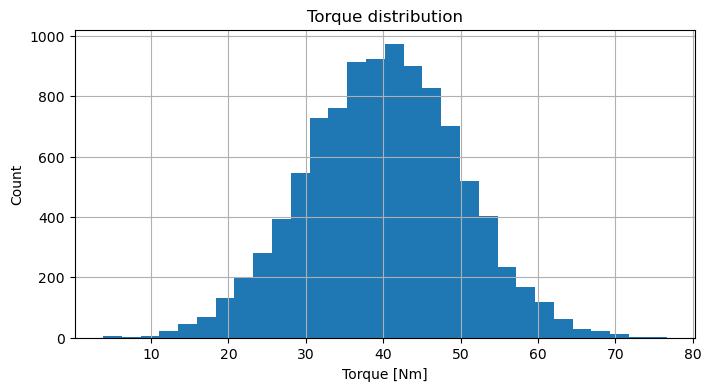

In [16]:
# 히스토그램
df["Torque [Nm]"].hist(bins=30)
plt.title("Torque distribution")
plt.xlabel("Torque [Nm]")
plt.ylabel("Count")
plt.show()

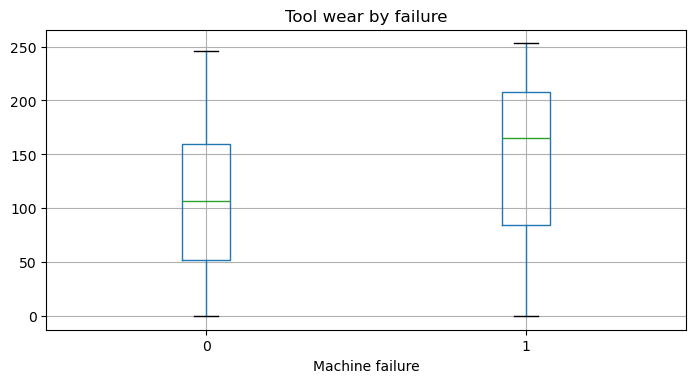

In [17]:
# 박스플롯
df.boxplot(column="Tool wear [min]", by="Machine failure")
plt.title("Tool wear by failure")
plt.suptitle("")
plt.show()

3. 컬럼을 하나씩 쉽게 이해하기

3-1. UID

각 행의 고유 번호입니다.
1부터 10000까지의 식별자라고 보면 됩니다. 분석용 변수라기보다 행 구분용 번호입니다. 보통 EDA나 ML에서는 설명 변수로 거의 쓰지 않습니다.

3-2. Product ID

제품 식별자입니다.
UCI 설명에 따르면 제품 ID는 L, M, H 문자와 일련번호로 구성되며, 이 문자는 제품 품질 변형(quality variant)을 뜻합니다. 다만 Product ID는 사실상 식별자 성격이 강해서 그대로 모델에 넣으면 과적합이나 의미 없는 패턴이 생길 수 있습니다. 수업에서는 보통 Type만 남기고 Product ID는 참고용으로 보는 편이 좋습니다.

3-3. Type

제품 타입 또는 품질 등급입니다.
UCI 설명상 L, M, H는 각각 low 50%, medium 30%, high 20% 비율의 제품 품질 변형입니다. 학생 입장에서는 “기계 상태”가 아니라 “생산되는 제품 종류”라고 생각하면 됩니다. 이 변수는 고장률 비교에서 자주 쓰입니다. 예를 들어 “어떤 타입에서 더 자주 고장 나는가?” 같은 질문을 할 수 있습니다.

3-4. Air temperature [K]

외기 온도입니다. 단위는 켈빈(K)입니다.
UCI 설명에서는 이 값이 랜덤 워크 기반으로 생성되고 약 300K 주변에서 움직이도록 정규화되었다고 설명합니다. 대학생이 헷갈리는 부분은 켈빈 단위인데, 대략 섭씨 = 켈빈 - 273.15로 생각하면 됩니다. 예를 들어 300K는 약 26.85℃입니다.

3-5. Process temperature [K]

공정 온도입니다. 역시 켈빈 단위입니다.
UCI 설명에서는 공정 온도가 외기 온도에 약 10K를 더한 수준에서 생성되었다고 설명합니다. 그래서 이 데이터에서는 Process temperature - Air temperature 차이를 보면 열 방출이나 공정 상태를 해석하는 데 도움이 됩니다. 실제로 일부 고장 모드는 이 온도 차이와 관련이 있습니다.

3-6. Rotational speed [rpm]

회전 속도입니다. 분당 회전 수(rpm)입니다.
쉽게 말해 축이나 스핀들이 얼마나 빨리 도는지 나타냅니다. 너무 느리거나 너무 빠르면 공정 조건이 달라질 수 있고, 다른 변수와 결합될 때 고장과 관련이 생깁니다. 이 데이터에서는 전력 관련 고장 모드와도 연결됩니다.

3-7. Torque [Nm]

토크입니다. 단위는 뉴턴미터(Nm)입니다.
토크는 쉽게 말해 “회전시키는 힘”입니다. 자전거 페달을 밟을 때 세게 밟으면 더 큰 힘이 걸리는 것과 비슷한 개념입니다. UCI 설명에 따르면 토크는 평균 40Nm 주변의 정규분포로 생성되며 음수 값은 없습니다. 제조에서 토크가 높다는 것은 기계에 더 큰 부하가 걸릴 가능성을 뜻할 수 있습니다.

3-8. Tool wear [min]

공구 마모 시간입니다. 단위는 분(min)입니다.
쉽게 말해 공구가 얼마나 오래 사용되어 닳았는지를 나타냅니다. UCI 설명에 따르면 제품 타입 H/M/L에 따라 공정에 더해지는 마모 시간이 각각 5/3/2분입니다. 제조 현장에서는 공구가 오래 쓰일수록 품질 저하나 고장 위험이 커질 수 있으므로 매우 중요한 변수입니다.

3-9. Machine failure

전체 고장 여부입니다.
0이면 고장 없음, 1이면 고장 발생입니다. 중요한 점은 이 값이 하나의 독립 규칙으로 만들어진 것이 아니라, 아래의 여러 고장 모드 중 하나라도 참이면 1이 된다는 점입니다. 즉, Machine failure는 “최종 결과 요약” 컬럼입니다.

3-10. TWF, HDF, PWF, OSF, RNF

이 다섯 개는 고장 원인 플래그입니다.
각각은 아래 의미를 가집니다.

TWF: Tool Wear Failure
공구 마모 때문에 고장

HDF: Heat Dissipation Failure
열 방출 문제 때문에 고장

PWF: Power Failure
필요한 동력 조건 문제로 고장

OSF: Overstrain Failure
과부하/과변형 때문에 고장

RNF: Random Failure
랜덤하게 발생한 드문 고장

자주 헷갈리는 점은
“그럼 Machine failure와 이 다섯 개는 중복 아닌가요?”
라는 부분인데, 맞습니다. 어느 정도 중복입니다.
정확히는 다섯 개가 세부 원인, Machine failure가 최종 종합 결과입니다.
그래서 보통 두 가지 방식으로 다룹니다.

전체 고장 예측을 하고 싶으면 Machine failure를 타깃으로 본다.

고장 원인 분석을 하고 싶으면 TWF~RNF를 함께 본다.

In [18]:
# 4-1. CSV 바로 조회
# DuckDB 공식 문서상 CSV reader는 자동 추론을 지원하므로, 간단하게 시작
con = duckdb.connect()

con.sql("""
SELECT *
FROM read_csv_auto('ai4i2020.csv')
LIMIT 5
""").df()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [19]:
# 4-2. 테이블 생성
con.sql("""
CREATE OR REPLACE TABLE ai4i AS
SELECT *
FROM read_csv_auto('ai4i2020.csv')
""")

In [20]:
# 4-3. 전체 건수와 고장률
con.sql("""
SELECT
    COUNT(*) AS n,
    AVG("Machine failure") AS failure_rate
FROM ai4i
""").df()

,n,failure_rate
0,10000,0.0339


In [21]:
# 4-4. 타입별 고장률
con.sql("""
SELECT
    Type,
    COUNT(*) AS n,
    ROUND(AVG("Machine failure"), 4) AS failure_rate
FROM ai4i
GROUP BY Type
ORDER BY failure_rate DESC
""").df()

,Type,n,failure_rate
0,L,6000,0.0392
1,M,2997,0.0277
2,H,1003,0.0209


In [22]:
# 4-5. 고장/정상 평균 비교
con.sql("""
SELECT
    "Machine failure",
    AVG("Air temperature [K]") AS air_temp_avg,
    AVG("Process temperature [K]") AS process_temp_avg,
    AVG("Rotational speed [rpm]") AS rotational_speed_avg,
    AVG("Torque [Nm]") AS torque_avg,
    AVG("Tool wear [min]") AS tool_wear_avg
FROM ai4i
GROUP BY "Machine failure"
ORDER BY "Machine failure"
""").df()

,Machine failure,air_temp_avg,process_temp_avg,rotational_speed_avg,torque_avg,tool_wear_avg
0,0,299.973999,309.995570,1540.260014,39.629655,106.693717
1,1,300.886431,310.290265,1496.486726,50.168142,143.781711


In [23]:
# 4-6. 파생변수 포함 분석
con.sql("""
SELECT
    "Machine failure",
    AVG("Process temperature [K]" - "Air temperature [K]") AS temp_diff_avg
FROM ai4i
GROUP BY "Machine failure"
""").df()

,Machine failure,temp_diff_avg
0,0,10.021571
1,1,9.403835


In [24]:
# 4-7. 공구 마모 구간별 고장률
con.sql("""
SELECT
    CASE
        WHEN "Tool wear [min]" <= 50 THEN '0-50'
        WHEN "Tool wear [min]" <= 100 THEN '51-100'
        WHEN "Tool wear [min]" <= 150 THEN '101-150'
        WHEN "Tool wear [min]" <= 200 THEN '151-200'
        ELSE '201+'
    END AS wear_group,
    COUNT(*) AS n,
    ROUND(AVG("Machine failure"), 4) AS failure_rate
FROM ai4i
GROUP BY wear_group
ORDER BY wear_group
""").df()

,wear_group,n,failure_rate
0,0-50,2396,0.0217
1,101-150,2295,0.0218
2,151-200,2276,0.0290
3,201+,762,0.1549
4,51-100,2271,0.0233


In [25]:
# 4-8. 토크 구간별 고장률
con.sql("""
SELECT
    CASE
        WHEN "Torque [Nm]" < 30 THEN 'under 30'
        WHEN "Torque [Nm]" < 40 THEN '30-39'
        WHEN "Torque [Nm]" < 50 THEN '40-49'
        WHEN "Torque [Nm]" < 60 THEN '50-59'
        ELSE '60+'
    END AS torque_group,
    COUNT(*) AS n,
    ROUND(AVG("Machine failure"), 4) AS failure_rate
FROM ai4i
GROUP BY torque_group
ORDER BY torque_group
""").df()

,torque_group,n,failure_rate
0,30-39,3364,0.0056
1,40-49,3487,0.0189
2,50-59,1334,0.0832
3,60+,239,0.4184
4,under 30,1576,0.0273


In [26]:
# 4-9. 타입 내 위험 순위 보기: 윈도우 함수
# DuckDB는 윈도우 함수와 QUALIFY를 지원하므로, “타입별 상위 위험 샘플” 같은 실습이 가능

con.sql("""
SELECT
    Type,
    "Torque [Nm]",
    "Tool wear [min]",
    "Machine failure",
    ROW_NUMBER() OVER (
        PARTITION BY Type
        ORDER BY "Torque [Nm]" DESC, "Tool wear [min]" DESC
    ) AS rn
FROM ai4i
QUALIFY rn <= 5
ORDER BY Type, rn
""").df()

,Type,Torque [Nm],Tool wear [min],Machine failure,rn
0,H,72.8,159,1,1
1,H,68.6,161,1,2
2,H,67.9,30,0,3
3,H,65.3,208,1,4
4,H,63.6,137,0,5
5,L,76.6,3,1,1
6,L,75.4,172,1,2
7,L,73.6,49,1,3
8,L,71.8,149,1,4
9,L,71.6,31,1,5


In [27]:
# 4-10. 고장 유형별 발생 건수
con.sql("""
SELECT 'TWF' AS failure_type, SUM(TWF) AS cnt FROM ai4i
UNION ALL
SELECT 'HDF', SUM(HDF) FROM ai4i
UNION ALL
SELECT 'PWF', SUM(PWF) FROM ai4i
UNION ALL
SELECT 'OSF', SUM(OSF) FROM ai4i
UNION ALL
SELECT 'RNF', SUM(RNF) FROM ai4i
ORDER BY cnt DESC
""").df()

,failure_type,cnt
0,HDF,115.0
1,OSF,98.0
2,PWF,95.0
3,TWF,46.0
4,RNF,19.0


In [28]:
# end